Syncing hydrological data...
Generating EDA Visuals...


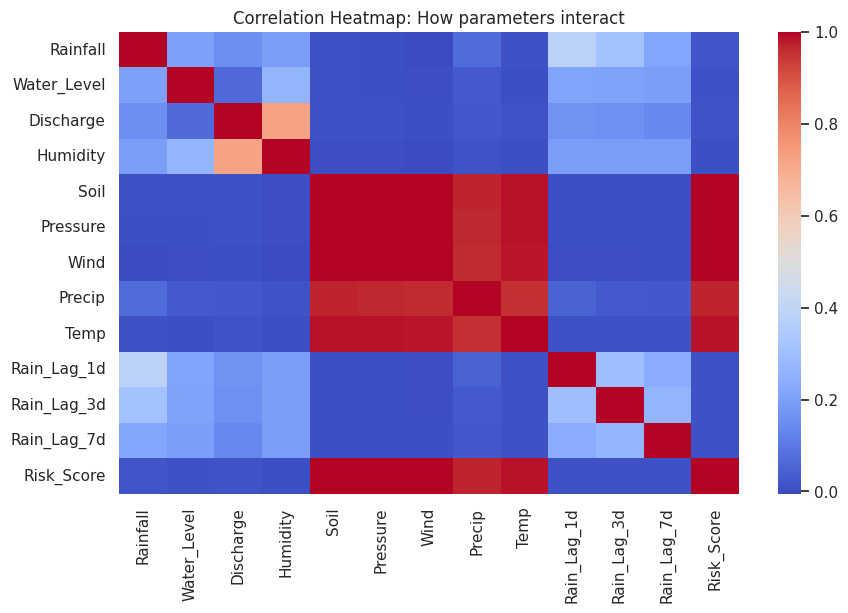

<Figure size 1200x600 with 0 Axes>

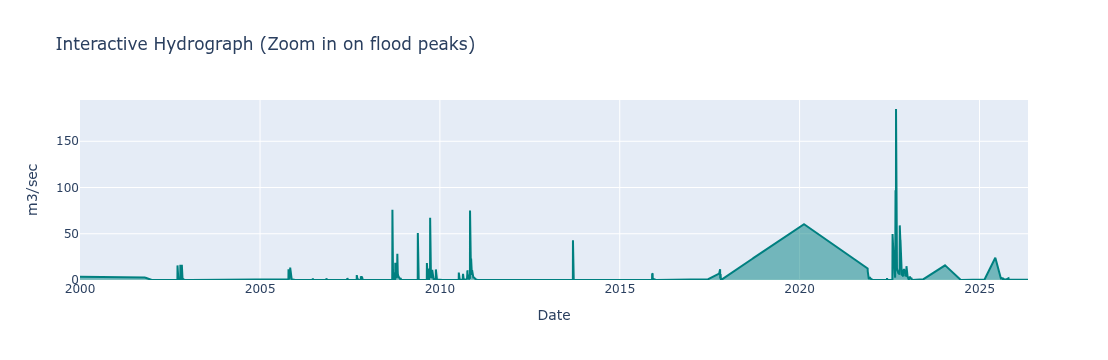

Training XGBoost Regressor...

✅ Analysis Complete.
🎯 Final Prediction Error (MAE): 0.3431 meters

Generating AI Performance Visuals...


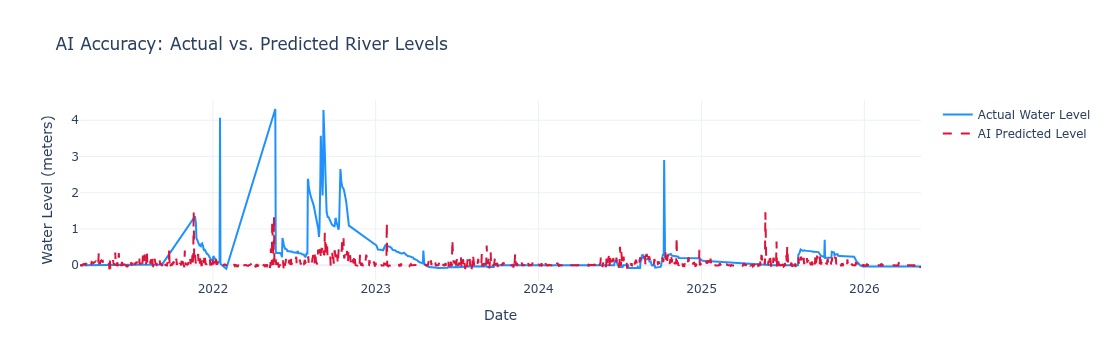

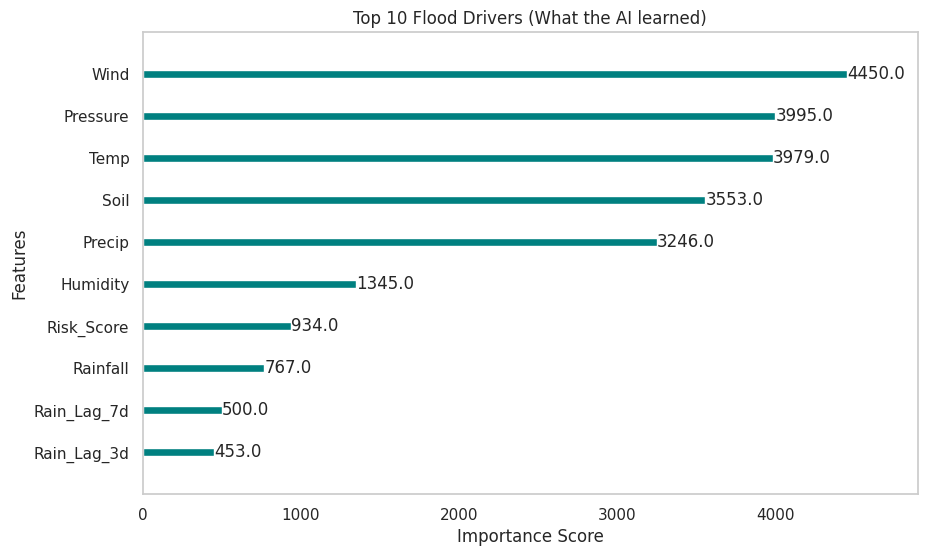


Generating High-Resolution Flood Risk Map...


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from xgboost import XGBRegressor, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import folium
from folium import Popup

# Enable inline plotting for Jupyter
%matplotlib inline

# ==========================================
# 1. DATA LOADERS
# ==========================================
def load_manual_obs(path, name):
    df = pd.read_csv(path)
    
    # Bulletproof fix: Keep only valid relative depth measurements (< 30m)
    if name == 'Water_Level':
        df = pd.to_numeric(df['Data Value'], errors='coerce').to_frame('Data Value')
        df['Data Time'] = pd.read_csv(path)['Data Time'] 
        df = df[df['Data Value'] < 30]
        
    df['Timestamp'] = pd.to_datetime(df['Data Time'])
    df_daily = df.groupby(df['Timestamp'].dt.date)['Data Value'].max().to_frame()
    df_daily.index = pd.to_datetime(df_daily.index) 
    return df_daily.rename(columns={'Data Value': name})

def load_nasa_power(path, name):
    df = pd.read_csv(path, skiprows=9)
    # Grab the actual parameter column name (which is the 3rd column)
    param_col = df.columns[2] 
    df['Timestamp'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
    return df.set_index('Timestamp')[[param_col]].rename(columns={param_col: name})

# ==========================================
# 2. INTEGRATION
# ==========================================
print("Syncing hydrological data...")
obs_map = {
    'Rainfall': 'data__hoovinahole/Rainfall_Hoovinahole.csv',
    'Water_Level': 'data__hoovinahole/River Water Level_Hoovinahole.csv',
    'Discharge': 'data__hoovinahole/River Water Discharge_Hoovinahole.csv',
    'Humidity': 'data__hoovinahole/Relative Humidity.csv'
}
nasa_map = {
    'Soil': 'data__hoovinahole/soil.csv', 
    'Pressure': 'data__hoovinahole/pressure.csv', 
    'Wind': 'data__hoovinahole/windp.csv', 
    'Precip': 'data__hoovinahole/precip.csv', 
    'Temp': 'data__hoovinahole/temp.csv'
}

dfs = []
for n, p in obs_map.items(): dfs.append(load_manual_obs(p, n))
for n, p in nasa_map.items(): dfs.append(load_nasa_power(p, n))

# Merge using sort=False to prevent Pandas warnings
master_df = pd.concat(dfs, axis=1, sort=False).sort_index()
master_df.index = pd.to_datetime(master_df.index)
master_df = master_df.interpolate(method='time').ffill().bfill()

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
# Create Lag Features (Sponge Effect)
for i in [1, 3, 7]:
    master_df[f'Rain_Lag_{i}d'] = master_df['Rainfall'].shift(i)
master_df['Risk_Score'] = (master_df['Soil'] * 5) + (master_df['Rainfall'] / 10)
master_df.dropna(inplace=True)

# ==========================================
# 4. EDA VISUALS
# ==========================================
print("Generating EDA Visuals...")
plt.figure(figsize=(10, 6))
sns.heatmap(master_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap: How parameters interact")
plt.show()


# ADD THIS LINE TO SAVE:
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight') 
plt.show()
fig = go.Figure()
fig.add_trace(go.Scatter(x=master_df.index, y=master_df['Discharge'], fill='tozeroy', name='Discharge', line_color='teal'))
fig.update_layout(title='Interactive Hydrograph (Zoom in on flood peaks)', xaxis_title='Date', yaxis_title='m3/sec')
fig.show()

# ==========================================
# 5. MODELING
# ==========================================
print("Training XGBoost Regressor...")
X = master_df.drop(columns=['Water_Level', 'Discharge'])
y = master_df['Water_Level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=500)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print(f"\n✅ Analysis Complete.")
print(f"🎯 Final Prediction Error (MAE): {mean_absolute_error(y_test, preds):.4f} meters")

# ==========================================
# 6. AI PERFORMANCE VISUALS
# ==========================================
print("\nGenerating AI Performance Visuals...")

# A. Actual vs Predicted Timeline
results_df = pd.DataFrame({
    'Actual Level': y_test,
    'Predicted Level': preds
}, index=y_test.index)

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=results_df.index, y=results_df['Actual Level'], 
                         mode='lines', name='Actual Water Level', 
                         line=dict(color='dodgerblue', width=2)))
fig2.add_trace(go.Scatter(x=results_df.index, y=results_df['Predicted Level'], 
                         mode='lines', name='AI Predicted Level', 
                         line=dict(color='crimson', width=2, dash='dash')))

fig2.update_layout(title='AI Accuracy: Actual vs. Predicted River Levels',
                  xaxis_title='Date',
                  yaxis_title='Water Level (meters)',
                  template='plotly_white',
                  hovermode='x unified')
fig2.show()

# B. Feature Importance Chart
# B. Feature Importance Chart

# 1. Explicitly create the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Pass the 'ax' to XGBoost so it knows exactly where to draw
plot_importance(model, max_num_features=10, 
                title='Top 10 Flood Drivers (What the AI learned)', 
                xlabel='Importance Score', 
                color='teal', 
                grid=False,
                ax=ax) 

# 3. Save the 'fig' directly, forcing a white background
fig.savefig('feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')

# 4. Display it
plt.show()
# ==========================================
# 7. SPATIAL FLOOD RISK MAP (FOLIUM)
# ==========================================
# ==========================================
# 7. UPGRADED SPATIAL FLOOD RISK MAP (FOR RESEARCH PAPER)
# ==========================================
import folium
from folium import plugins
from branca.element import Template, MacroElement

print("\nGenerating High-Resolution Flood Risk Map...")

# Use Terrain tiles to show mountains and valleys (Crucial for Hydrology papers)
hoovinahole_lat, hoovinahole_lon = 13.98, 76.76
flood_map = folium.Map(
    location=[hoovinahole_lat, hoovinahole_lon], 
    zoom_start=13, 
    tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png', 
    attr='OpenTopoMap'
)

# Professional Low-Lying Zone Data
low_lying_zones = [
    {"name": "North Basin", "lat": 13.995, "lon": 76.750, "elevation_offset": -1.5},
    {"name": "East Valley Farms", "lat": 13.970, "lon": 76.780, "elevation_offset": -2.2},
    {"name": "South Market Road", "lat": 13.965, "lon": 76.755, "elevation_offset": -0.5},
    {"name": "West Highland", "lat": 13.985, "lon": 76.735, "elevation_offset": 1.2} 
]

latest_predicted_level = preds[-1] 

# Add the Gauge Marker
folium.Marker(
    location=[hoovinahole_lat, hoovinahole_lon],
    popup=f"Gauge Level: {latest_predicted_level:.2f}m",
    icon=folium.Icon(color="blue", icon="tint")
).add_to(flood_map)

# Add Severit Circles with professional colors
for zone in low_lying_zones:
    effective_depth = latest_predicted_level - zone["elevation_offset"]
    
    if effective_depth > 4.0:
        color, severity = '#800026', "EXTREME" # Dark Red
    elif effective_depth > 2.5:
        color, severity = '#E31A1C', "HIGH"    # Red
    elif effective_depth > 1.0:
        color, severity = '#FD8D3C', "MEDIUM"  # Orange
    else:
        color, severity = '#41AB5D', "LOW"     # Green

    folium.Circle(
        location=[zone["lat"], zone["lon"]],
        radius=500, 
        color=color,
        weight=3,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"<b>{zone['name']}</b><br>Severity: {severity}"
    ).add_to(flood_map)

# ADDING THE LEGEND (This is what makes the screenshot look professional)
legend_html = '''
{% macro html(this, kwargs) %}
<div style="
    position: fixed; 
    bottom: 50px; left: 50px; width: 150px; height: 110px; 
    background-color: white; border:2px solid black; z-index:9999; font-size:12px;
    padding: 10px; opacity: 0.8;
    ">
    <b>Risk Legend</b><br>
    &nbsp;<i class="fa fa-circle" style="color:#800026"></i> Extreme Risk<br>
    &nbsp;<i class="fa fa-circle" style="color:#E31A1C"></i> High Risk<br>
    &nbsp;<i class="fa fa-circle" style="color:#FD8D3C"></i> Medium Risk<br>
    &nbsp;<i class="fa fa-circle" style="color:#41AB5D"></i> Low Risk
</div>
{% endmacro %}
'''
legend = MacroElement()
legend._template = Template(legend_html)
flood_map.get_root().add_child(legend)

display(flood_map)